# 


<h1 style="
color:#1E5A96;
font-size:40px;
font-weight:800;
line-height:1.25;
margin:0;
">
Capstone Project: Predicting Property Prices using Machine Learning
</h1>




<h3 style="color:#B8860B;font-size:22px;margin:0 0 10px 0;">
Prepared By
</h3>
<p style="color:#B8860B;font-size:22px;margin:0;"> 
<b>OM PRAKASH</b>
</p> 





**GOAL**: Build a predictive model to estimate property prices (`PropPrice`) based on a rich set of 80 features, achieving a target $R^2$ score above 85%.

<h2><span style="color:lightblue"><b>Introduction</b></span></h2>



The real estate market is highly dynamic and represents one of the most significant components of personal wealth and institutional investment. Predicting property prices accurately is critical for developers, buyers, sellers, and mortgage lenders. This capstone project leverages the Ames Housing dataset, which consists of 1,460 properties and 80 explanatory variables describing various aspects of residential homes. Using machine learning algorithms such as Ridge, Lasso, Random Forests, and Gradient Boosting Regressors, we develop an end-to-end predictive pipeline capable of estimating home values with high precision. In doing so, we address challenges such as missing values, skewed distributions, multicollinearity, and high dimensionality.



<h2><span style="color:lightblue"><b>Project vision</b></span></h2>


From Property Characteristics to Price Intelligence

<b>
Develop an accurate, interpretable, and data-driven Machine Learning framework capable of transforming property characteristics into reliable property price predictions.
</b>


<h2><span style="color:lightblue"><b>Objectives</b></span></h2>

This project analyzes housing characteristics and builds a machine learning regression pipeline to predict property prices. The primary technical and analytical objectives of this project are:


1. Data Collection & Preprocessing: Establish an automated cleaning pipeline to handle missing values, anomalies, and outliers.
2. Variable Categorization: Distinguish between ordinal and nominal columns, applying appropriate mappings and one-hot encodings.
3. Feature Scaling & PCA: Leverage StandardScaler and Principal Component Analysis to compare dimensionality reduction vs. full feature sets.
4. Predictive Modeling: Evaluate linear regression variants alongside decision trees and ensemble algorithms.
5. Optimization & Validation: Tune model hyperparameters using GridSearchCV cross-validation to maximize the test R2 score, targeting over 85%.


<h2><span style="color:lightblue"><b>Library Setup</b></span></h2>

In [6]:
import warnings
import numpy as np
import pandas as pd
import streamlit as st
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    RobustScaler,
    PowerTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_regression
)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.inspection import permutation_importance
from IPython.display import display
import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# --- SETUP DIRECTORIES AND MATPLOTLIB STYLE ---
os.makedirs('plots', exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.figsize': (10, 6)
})

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.



<h2><span style="color:lightblue"><b>Data Loading and Preprocessing</b></span></h2>

In [7]:
df = pd.read_csv('Property_data (1) (1).csv')
print(f"Shape of dataset: {df.shape}")
df.head()

Shape of dataset: (1460, 81)


,PropertyID,PropertyClass,PropertyZone,PropertyFrontage,PropertySize,Street,Alley,PropertyShape,Elevation,Amenities,Orientation,Grade,Neighborhood,Condition1,Condition2,BldgType,PropertyStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Roof1Material,Roof2Material,ExteriorCladdingType,ExteriorCladdingArea,ExterQual,ExterCond,PropertyFooting,BsmntFinish,BsmntMaintenance,BsmntVisibility,BsmntFinRat1,BsmntFinSty1,BsmntFinQual1,BsmtFinSF2,BsmtUnfSF,BsmntSqFtage,Heating,HeatingEfficiency,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,Bath1,Bath2,BedroomUpLev,KitchenUpLev,KitchenQual,CntRmsUpLev,Functional,CntFireplaces,QualFireplace,BasementType,BasementYrBlt,BasementFinish,BasementCars,BasementSqFootage,BasementQual,BasementCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,BoundaryFeatures,AddFeatures,AddVal,SaleMon,SaleYr,SaleType,SaleCondn,PropPrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.00",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.00",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.00",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.00",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.00",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<h2><span style="color:lightblue"><b>Data Cleaning and Outlier Removal</b></span></h2>


A standard rule for the Ames housing dataset is to remove extreme outliers where properties have large ground living area but sold for very low prices (e.g. GrLivArea > 4000 sqft and price < $300,000).

<h2><span style="color:lightblue"><b>Plotting before outlier removal</b></span></h2>

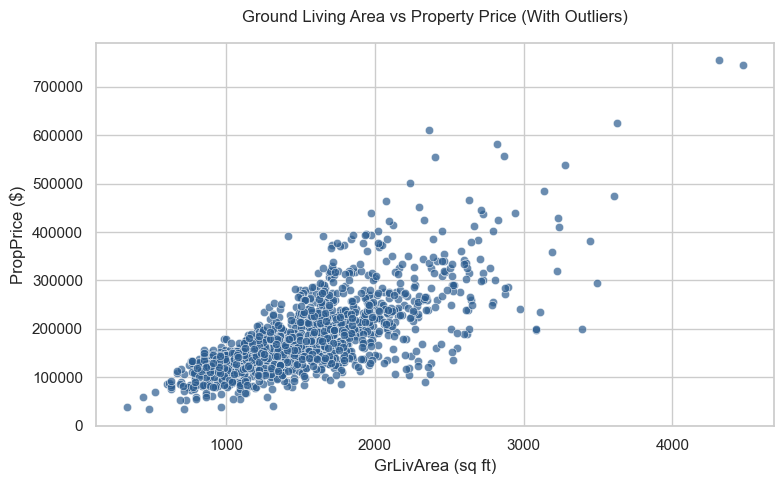

In [ ]:
# 1. Outlier Removal (using standard Ames Housing criteria for GrLivArea vs Price)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='GrLivArea', y='PropPrice', alpha=0.7, color='#2b5c8f')
plt.title("Ground Living Area vs Property Price (With Outliers)", pad=15)
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("PropPrice ($)")
plt.tight_layout()
plt.savefig('plots/outliers_before.png', dpi=150)
plt.show()
plt.close()

<h2><span style="color:lightblue"><b>Outlier removal</b></span></h2>

In [8]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='GrLivArea', y='PropPrice', color='#2b5c8f')
plt.title("GrLivArea vs PropPrice (Before Outlier Removal)")
plt.show()

outliers = df[(df['GrLivArea'] > 4000) & (df['PropPrice'] < 300000)]
df = df.drop(outliers.index).reset_index(drop=True)
print(f"Removed {len(outliers)} outliers. New shape: {df.shape}")

Removed 2 outliers. New shape: (1458, 81)


<h2><span style="color:lightblue"><b> Plotting after outlier removal</b></span></h2>

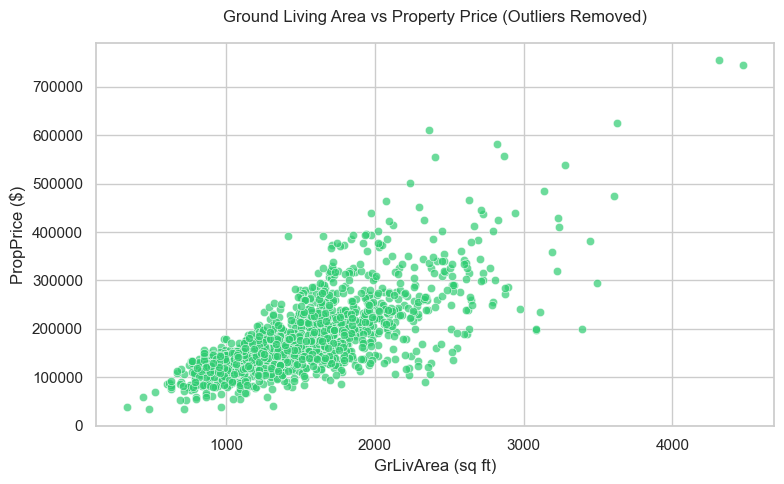

In [24]:
# Plotting after outlier removal
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='GrLivArea', y='PropPrice', alpha=0.7, color='#2ecc71')
plt.title("Ground Living Area vs Property Price (Outliers Removed)", pad=15)
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("PropPrice ($)")
plt.tight_layout()
plt.savefig('plots/outliers_after.png', dpi=150)
plt.show()
plt.close()



Shape: (1458, 81)
   GrLivArea  PropPrice
0       1710     208500
1       1262     181500
2       1786     223500
3       1717     140000
4       2198     250000

Missing values:
GrLivArea    0
PropPrice    0
dtype: int64


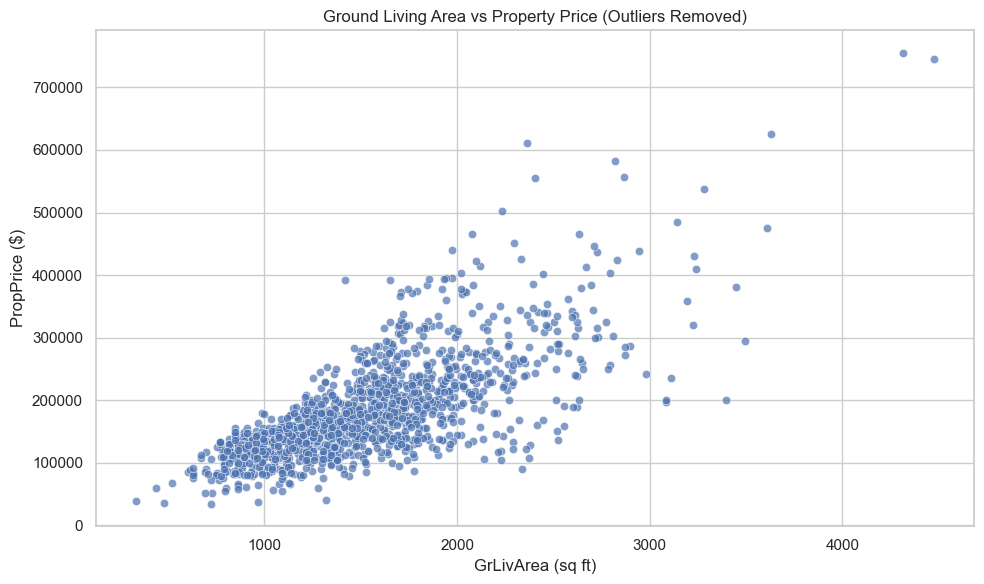

In [27]:
%matplotlib inline

# Check data first
print("Shape:", df.shape)
print(df[["GrLivArea", "PropPrice"]].head())

# Check missing values
print("\nMissing values:")
print(df[["GrLivArea", "PropPrice"]].isna().sum())

# Plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df["GrLivArea"],
    y=df["PropPrice"],
    alpha=0.7
)

plt.title("Ground Living Area vs Property Price (Outliers Removed)")
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("PropPrice ($)")
plt.tight_layout()

plt.show()

<h2><span style="color:lightblue"><b>Missing Value Analysis & Treatment</b></span></h2>




Missing values are analysed according to their **feature meaning and data type**.  
Property-related attributes where missingness represents the **absence of a facility or component** are treated separately from genuinely missing numerical measurements.


<h2><span style="color:lightblue"><b>Imputation of Missing Values</b></span></h2>

- For optional categorical elements, replace null with `'None'` (e.g., Garage, Pool, Basement features).
- For continuous variables, replace null with median or zero depending on the column.

In [11]:
# 2. Imputation of Missing Values

none_impute_cols = [
    'Alley', 'ExteriorCladdingType', 'QualFireplace', 'BasementType', 
    'BasementFinish', 'BasementQual', 'BasementCond', 'BsmntFinish', 
    'BsmntMaintenance', 'BsmntVisibility', 'BsmntFinRat1', 'BsmntFinQual1', 
    'PoolQC', 'BoundaryFeatures', 'AddFeatures'
]
for col in none_impute_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

mode_impute_cols = ['Electrical']
for col in mode_impute_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

if 'PropertyFrontage' in df.columns and 'Neighborhood' in df.columns:
    df['PropertyFrontage'] = df.groupby('Neighborhood')['PropertyFrontage'].transform(lambda x: x.fillna(x.median()))
    df['PropertyFrontage'] = df['PropertyFrontage'].fillna(df['PropertyFrontage'].median())

if 'BasementYrBlt' in df.columns and 'YearBuilt' in df.columns:
    df['BasementYrBlt'] = df['BasementYrBlt'].fillna(df['YearBuilt'])

zero_impute_cols = ['ExteriorCladdingArea']
for col in zero_impute_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)
print("Imputing missing values...")
print(f"Remaining null counts: {df.isnull().sum().sum()}")

Imputing missing values...
Remaining null counts: 0


In [12]:
none_cols = [
    'Alley', 'ExteriorCladdingType', 'QualFireplace', 'BasementType', 
    'BasementFinish', 'BasementQual', 'BasementCond', 'BsmntFinish', 
    'BsmntMaintenance', 'BsmntVisibility', 'BsmntFinRat1', 'BsmntFinQual1', 
    'PoolQC', 'BoundaryFeatures', 'AddFeatures'
]
for col in none_cols:
    df[col] = df[col].fillna('None')

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
df['PropertyFrontage'] = df.groupby('Neighborhood')['PropertyFrontage'].transform(lambda x: x.fillna(x.median()))
df['PropertyFrontage'] = df['PropertyFrontage'].fillna(df['PropertyFrontage'].median())
df['BasementYrBlt'] = df['BasementYrBlt'].fillna(df['YearBuilt'])
df['ExteriorCladdingArea'] = df['ExteriorCladdingArea'].fillna(0)

print(f"Remaining missing values in dataset: {df.isnull().sum().sum()}")

Remaining missing values in dataset: 0


<h2><span style="color:lightblue"><b>Feature Classification</b></span></h2>




Features are classified according to their **statistical and semantic characteristics** before encoding.  
Ordinal variables preserve a meaningful ranking, nominal variables represent unordered categories, while numerical variables retain measurable quantitative information.

This separation ensures that each feature group receives an appropriate preprocessing strategy without introducing artificial relationships between categories.

In [15]:
# ============================================================
# FEATURE TYPE CLASSIFICATION
# ============================================================

ordinal_cols = [
    "PropertyShape",
    "Grade",
    "OverallQual",
    "OverallCond",
    "ExterQual",
    "ExterCond",
    "BsmntFinish",
    "BsmntMaintenance",
    "BsmntVisibility",
    "BsmntFinRat1",
    "BsmntFinQual1",
    "HeatingEfficiency",
    "KitchenQual",
    "Functional",
    "QualFireplace",
    "BasementFinish",
    "BasementQual",
    "BasementCond",
    "PavedDrive",
    "PoolQC"
]

# PropertyClass is treated as nominal
nominal_cols = [
    c
    for c in df.select_dtypes(exclude=np.number).columns
    if c not in ordinal_cols
]

if "PropertyClass" in df.columns:
    nominal_cols.append("PropertyClass")

# Numerical columns
numeric_cols = [
    c
    for c in df.select_dtypes(include=np.number).columns
    if c not in ordinal_cols
    and c not in nominal_cols
]

# Remove duplicates while preserving order
ordinal_cols = list(dict.fromkeys(ordinal_cols))
nominal_cols = list(dict.fromkeys(nominal_cols))
numeric_cols = list(dict.fromkeys(numeric_cols))


# ============================================================
# FEATURE CLASSIFICATION SUMMARY
# ============================================================

feature_types = pd.DataFrame({
    "Feature Type": [
        "Numerical",
        "Ordinal",
        "Nominal"
    ],
    "Count": [
        len(numeric_cols),
        len(ordinal_cols),
        len(nominal_cols)
    ],
    "Preprocessing": [
        "Imputation / Scaling where required",
        "Ordinal Encoding",
        "Nominal Encoding"
    ]
})

display(
    (
        feature_types,
        "Feature Classification Summary"
    )
)


# ============================================================
# VALIDATION
# ============================================================

classified = set(
    numeric_cols +
    ordinal_cols +
    nominal_cols
)

all_features = set(df.columns)

unclassified = all_features - classified
duplicated = (
    set(numeric_cols) & set(ordinal_cols)
) | (
    set(numeric_cols) & set(nominal_cols)
) | (
    set(ordinal_cols) & set(nominal_cols)
)

print("Feature Classification")
print("-" * 40)
print(f"Numerical features : {len(numeric_cols)}")
print(f"Ordinal features   : {len(ordinal_cols)}")
print(f"Nominal features   : {len(nominal_cols)}")
print(f"Total classified   : {len(classified)}")

if unclassified:
    print("\n⚠️ Unclassified columns:")
    print(sorted(unclassified))
else:
    print("\n✅ All dataframe columns are classified.")

if duplicated:
    print("\n⚠️ Features appearing in multiple categories:")
    print(sorted(duplicated))
else:
    print("✅ No feature overlaps.")

(  Feature Type  Count                        Preprocessing
 0    Numerical     35  Imputation / Scaling where required
 1      Ordinal     20                     Ordinal Encoding
 2      Nominal     26                     Nominal Encoding,
 'Feature Classification Summary')

Feature Classification
----------------------------------------
Numerical features : 35
Ordinal features   : 20
Nominal features   : 26
Total classified   : 81

✅ All dataframe columns are classified.
✅ No feature overlaps.



<h2><span style="color:lightblue"><b>Exploratory Data Analysis</b></span></h2>



Exploratory Data Analysis is performed to understand the **distribution, variability, patterns, and relationships** present within the property dataset.

The analysis begins with the target variable, **`PropPrice`**, followed by numerical and categorical property characteristics. This helps identify potential price drivers, unusual observations, nonlinear relationships, and variables requiring transformation before modelling.


<h2><span style="color:lightblue"><b>Target Variable Analysis — Property Price Distribution</b></span></h2>


The first stage of Exploratory Data Analysis focuses on the target variable, **`PropPrice`**, because understanding its statistical behaviour is essential before analysing relationships with the predictor variables.

This analysis evaluates the **central tendency, dispersion, range, distribution shape, and skewness** of property prices. It helps determine whether prices are evenly distributed, concentrated within a specific range, or influenced by a smaller number of high-value properties.

The target distribution is also examined to identify whether any transformation may be useful during modelling and to ensure that extreme property values are interpreted carefully rather than removed without justification.


In [ ]:
target_summary = pd.DataFrame({
    "Metric": [
        "Mean Price", "Median Price", "Minimum Price",
        "Maximum Price", "Std. Deviation", "Skewness"
    ],
    "Value": [
        df[TARGET].mean(),
        df[TARGET].median(),
        df[TARGET].min(),
        df[TARGET].max(),
        df[TARGET].std(),
        df[TARGET].skew()
    ]
})

display(target_summary)



,Metric,Value
0,Mean Price,"180,932.92"
1,Median Price,"163,000.00"
2,Minimum Price,"34,900.00"
3,Maximum Price,"755,000.00"
4,Std. Deviation,"79,495.06"
5,Skewness,1.88


Data shape: (1458, 81)
PropPrice missing: 0
y_log shape: (1458,)


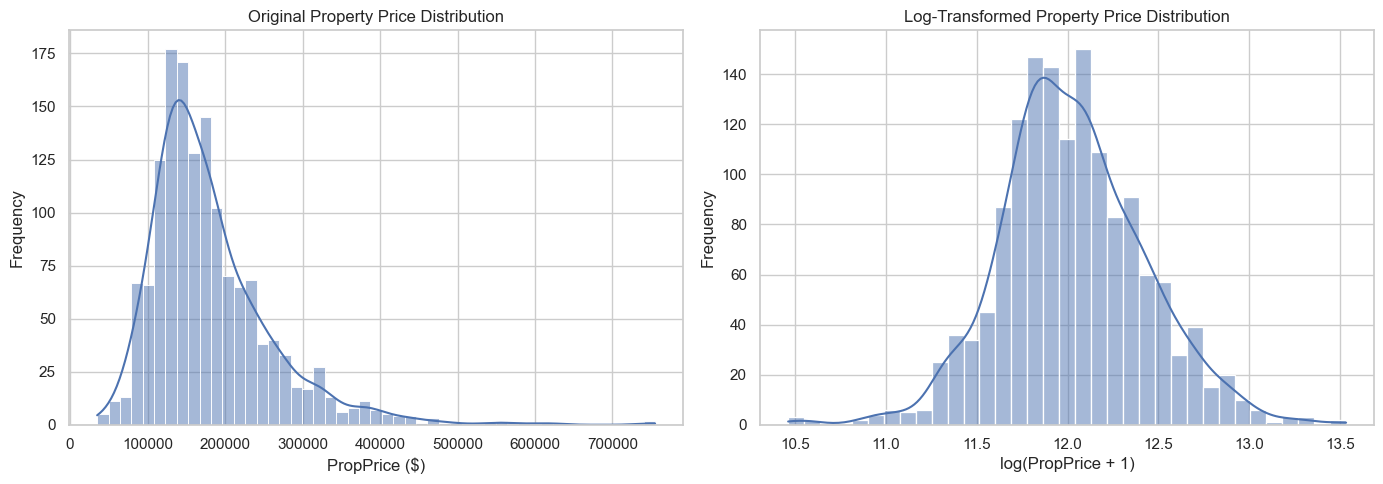

✅ Plot saved:
plots/price_distribution.png


In [32]:
# ==========================================
# EXTRA EDA PLOTS
# ==========================================

# Create plots folder
os.makedirs("plots", exist_ok=True)

# --------------------------------------------------
# Create log-transformed target if not already created
# --------------------------------------------------
y_log = np.log1p(df["PropPrice"])

# Check data
print("Data shape:", df.shape)
print("PropPrice missing:", df["PropPrice"].isna().sum())
print("y_log shape:", y_log.shape)

# --------------------------------------------------
# Target distribution before and after log transform
# --------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

# Original distribution
sns.histplot(
    df["PropPrice"].dropna(),
    kde=True,
    ax=axes[0]
)

axes[0].set_title(
    "Original Property Price Distribution"
)
axes[0].set_xlabel("PropPrice ($)")
axes[0].set_ylabel("Frequency")


# Log-transformed distribution
sns.histplot(
    y_log.dropna(),
    kde=True,
    ax=axes[1]
)

axes[1].set_title(
    "Log-Transformed Property Price Distribution"
)
axes[1].set_xlabel("log(PropPrice + 1)")
axes[1].set_ylabel("Frequency")


plt.tight_layout()

# Save figure
plt.savefig(
    "plots/price_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

# IMPORTANT: show BEFORE close
plt.show()

plt.close(fig)

print("✅ Plot saved:")
print("plots/price_distribution.png")

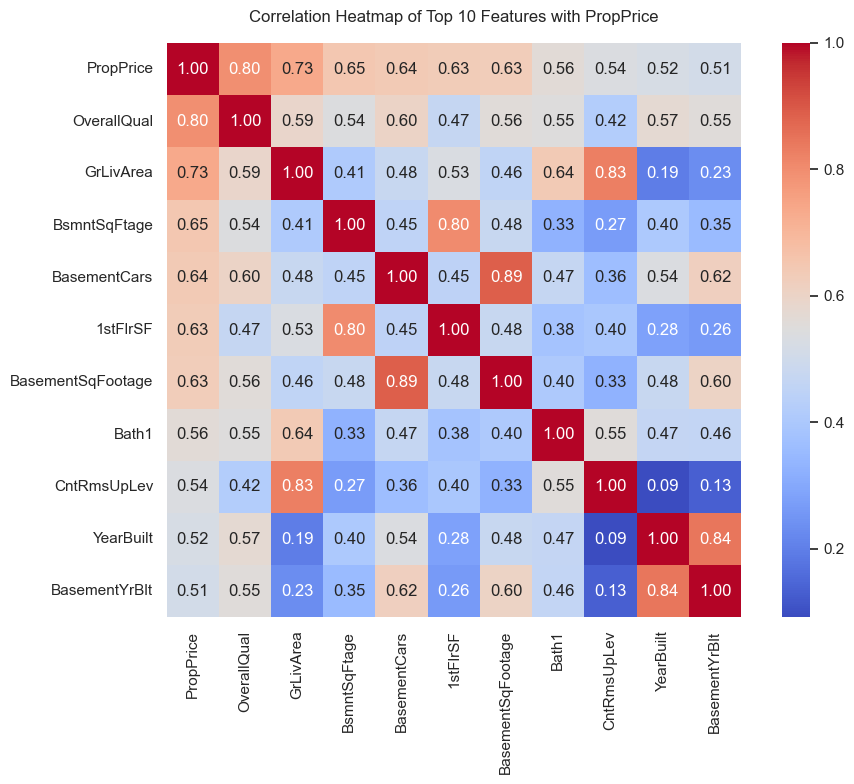

In [29]:
# 2. Correlation heatmap of top numeric features
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['PropertyID'])
correlations = numeric_cols.corr()['PropPrice'].sort_values(ascending=False)
top_corr_features = correlations.index[:11] # Top 10 correlated with target + target itself
corr_matrix = numeric_cols[top_corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap of Top 10 Features with PropPrice", pad=15)
plt.tight_layout()
plt.savefig('plots/correlation_matrix.png', dpi=150)
plt.show()
plt.close()


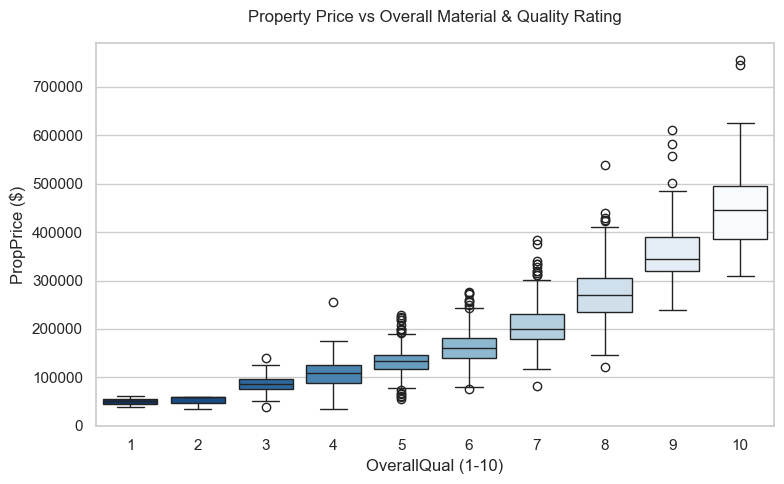

In [30]:
# 3. OverallQual Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='OverallQual', y='PropPrice', palette='Blues_r', hue='OverallQual', legend=False)
plt.title("Property Price vs Overall Material & Quality Rating", pad=15)
plt.xlabel("OverallQual (1-10)")
plt.ylabel("PropPrice ($)")
plt.tight_layout()
plt.savefig('plots/qual_boxplot.png', dpi=150)
plt.show()
plt.close()


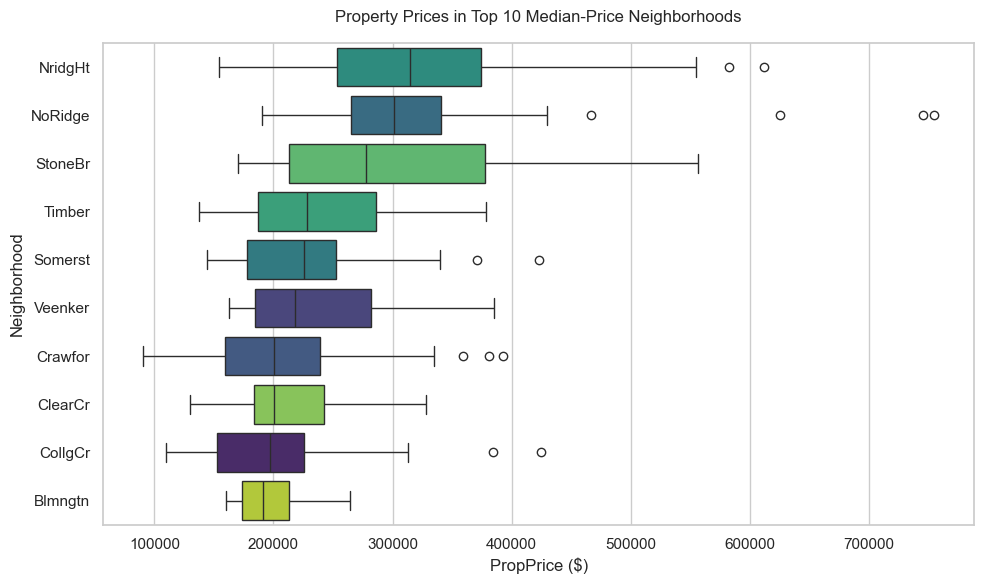

In [31]:
# 4. Neighborhood Boxplot (Top 10 highest-price neighborhoods)
top_neigh = df.groupby('Neighborhood')['PropPrice'].median().sort_values(ascending=False).index[:10]
df_top_neigh = df[df['Neighborhood'].isin(top_neigh)]
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top_neigh, x='PropPrice', y='Neighborhood', palette='viridis', order=top_neigh, hue='Neighborhood', legend=False)
plt.title("Property Prices in Top 10 Median-Price Neighborhoods", pad=15)
plt.xlabel("PropPrice ($)")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.savefig('plots/neighborhood_boxplot.png', dpi=150)
plt.show()
plt.close()



<h2><span style="color:lightblue"><b>Feature Engineering</b></span></h2>


Feature engineering transforms the existing property attributes into **more informative variables that better represent the underlying characteristics influencing property value**.

Rather than relying exclusively on the original columns, this stage combines related information and derives meaningful indicators representing aspects such as **property age, renovation recency, total usable area, bathroom capacity, outdoor space, and amenity availability**.

The objective is to strengthen the predictive information available to the machine-learning models while preserving the original property characteristics wherever appropriate.

The engineered features will focus on:

- **Property Age** — age of the property at the time of sale.
- **Remodel Age** — time elapsed since the most recent renovation.
- **Total Property Area** — combined basement and above-ground usable area.
- **Total Bathroom Capacity** — consolidated bathroom availability using full and half bathrooms.
- **Total Porch Area** — combined outdoor porch and deck space.
- **Garage / Basement Availability** — indicators identifying whether these facilities are present.
- **Property Improvement Status** — whether significant renovation has occurred.
- **Total Functional Space** — consolidated indicators of usable property capacity.
- **Amenity Presence** — indicators for facilities such as fireplaces, pools, garages, and additional property features.

Feature creation will remain **selective and domain-driven**. Redundant variables will not be generated merely to increase the number of predictors, and every engineered feature will be evaluated for its analytical relevance before modelling.



<b>Feature Engineering Principle:</b>  
Create features that improve the representation of the property rather than simply increasing dimensionality.



In [ ]:
new_features = {
    "PropertyAge": df["SaleYr"] - df["YearBuilt"],
    "RemodelAge": df["SaleYr"] - df["YearRemodAdd"],
    "TotalSF": df["BsmntSqFtage"] + df["1stFlrSF"] + df["2ndFlrSF"],
    "TotalBathrooms": (
        df["Bath1"] + 0.5 * df["Bath2"] +
        df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
    ),
    "TotalPorchSF": (
        df["WoodDeckSF"] + df["OpenPorchSF"] + df["EnclosedPorch"] +
        df["3SsnPorch"] + df["ScreenPorch"]
    ),
    "HasGarage": (df["BasementCars"] > 0).astype(int),
    "HasBasement": (df["BsmntSqFtage"] > 0).astype(int),
    "HasFireplace": (df["CntFireplaces"] > 0).astype(int),
    "HasPool": (df["PoolArea"] > 0).astype(int)
}

df = df.assign(**new_features)

engineered = pd.DataFrame({
    "Feature": new_features.keys(),
    "Purpose": [
        "Property age at sale",
        "Years since latest remodel",
        "Combined usable floor area",
        "Equivalent bathroom capacity",
        "Combined outdoor living area",
        "Garage availability",
        "Basement availability",
        "Fireplace availability",
        "Pool availability"
    ],
    "Correlation": [
        # df[c].corr(df[TARGET]) for c in new_features
    ]
}).round(3)

display(
    (
        engineered,
        "Engineered Feature Summary"
    )
)

print(f"Engineered Features : {len(new_features)}")
print(f"Final Dataset Shape : {df.shape}")

ValueError: All arrays must be of the same length


<h2><span style="color:lightblue"><b>Data Preprocessing & Encoding</b></span></h2>



TRAIN–VALIDATION PREPARATION • ORDINAL ENCODING • NOMINAL ENCODING • SCALING

Data preprocessing converts the cleaned and engineered property dataset into a **model-ready numerical representation** while preserving the analytical meaning of each feature.

Because the dataset contains a mixture of **numerical, ordinal, and nominal variables**, each feature group requires a different preprocessing strategy. Applying the same transformation to every variable could distort meaningful relationships or introduce artificial numerical order.

The project brief specifically requires **ordinal and nominal variables to be handled separately**, together with appropriate encoding, scaling, missing-value treatment, and PCA assessment.

### Preprocessing Strategy

* **Numerical Features** — retained as quantitative measurements and scaled where required to place variables with different magnitudes on a comparable scale.

* **Ordinal Features** — encoded according to their meaningful category hierarchy so that the natural ordering between quality or condition levels is preserved.

* **Nominal Features** — transformed using **One-Hot Encoding**, ensuring that unordered categories are represented without introducing an artificial ranking.

* **Property ID** — excluded from model predictors because it functions as an identifier rather than a meaningful property characteristic.

* **Target Variable (`PropPrice`)** — preserved separately and will not be included in feature preprocessing.

### Data Leakage Prevention

Before fitting any scaler, encoder, or transformation, the dataset will be divided into **training and validation subsets**.

All preprocessing operations will be **fitted only on the training data** and subsequently applied to the validation data. This prevents information from the validation set from influencing the transformation process and provides a more reliable estimate of model performance.

### Pipeline Architecture

**Property Features**
↓
**Train–Validation Split**
↓
**Numerical Processing** → Scaling
**Ordinal Processing** → Ordered Encoding
**Nominal Processing** → One-Hot Encoding
↓
**ColumnTransformer**
↓
**Model-Ready Feature Matrix**



<b>Preprocessing Principle:</b>
Transform each variable according to its statistical meaning while fitting every data-dependent transformation exclusively on the training data to preserve model validity.

</div>


In [19]:
TARGET = "PropPrice"
ID_COL = "PropertyID"
X = df.drop(columns=[TARGET, ID_COL])
y = df[TARGET]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=.20, random_state=42
)

ordinal_order = {
    "PropertyShape": ["IR3", "IR2", "IR1", "Reg"],
    "Grade": ["Sev", "Mod", "Gtl"],
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmntFinish": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmntMaintenance": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmntVisibility": ["None", "No", "Mn", "Av", "Gd"],
    "BsmntFinRat1": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmntFinQual1": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingEfficiency": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "QualFireplace": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "BasementFinish": ["None", "Unf", "RFn", "Fin"],
    "BasementQual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "BasementCond": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "PavedDrive": ["N", "P", "Y"],
    "PoolQC": ["None", "Po", "Fa", "TA", "Gd", "Ex"]
}

ord_cols = [c for c in ordinal_order if c in X.columns]
nom_cols = [
    c for c in X.select_dtypes(exclude=np.number)
    if c not in ord_cols
] + (["PropertyClass"] if "PropertyClass" in X.columns else [])

num_cols_model = [
    c for c in X.select_dtypes(include=np.number)
    if c not in nom_cols
]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), num_cols_model),

    ("ord", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(
            categories=[ordinal_order[c] for c in ord_cols],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ]), ord_cols),

    ("nom", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]), nom_cols)
])

X_train_p = preprocessor.fit_transform(X_train)
X_valid_p = preprocessor.transform(X_valid)

feature_names = preprocessor.get_feature_names_out()

X_train_p = pd.DataFrame(X_train_p, columns=feature_names, index=X_train.index)
X_valid_p = pd.DataFrame(X_valid_p, columns=feature_names, index=X_valid.index)

summary = pd.DataFrame({
    "Metric": [
        "Training Records", "Validation Records",
        "Numerical Features", "Ordinal Features",
        "Nominal Features", "Final Encoded Features"
    ],
    "Value": [
        len(X_train), len(X_valid),
        len(num_cols_model), len(ord_cols),
        len(nom_cols), X_train_p.shape[1]
    ]
})

display((summary, "Preprocessing Summary"))

print("Training Matrix  :", X_train_p.shape)
print("Validation Matrix:", X_valid_p.shape)
print("Missing Values   :", X_train_p.isna().sum().sum() + X_valid_p.isna().sum().sum())

(                   Metric  Value
 0        Training Records   1166
 1      Validation Records    292
 2      Numerical Features     35
 3        Ordinal Features     18
 4        Nominal Features     26
 5  Final Encoded Features    241,
 'Preprocessing Summary')

Training Matrix  : (1166, 241)
Validation Matrix: (292, 241)
Missing Values   : 0


<h2><span style="color:lightblue"><b>Ordinal category order</b></span></h2>

In [ ]:
# -------------------------------------------------
# Ordinal category order
# -------------------------------------------------

ordinal_categories = [
    # PropertyShape
    ["IR3", "IR2", "IR1", "Reg"],

    # Grade
    ["Po", "Fa", "TA", "Gd", "Ex"],

    # OverallQual
    ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"],

    # OverallCond
    ["1", "2", "3", "4", "5", "6", "7", "8", "9"],

    # ExterQual
    ["Po", "Fa", "TA", "Gd", "Ex"],

    # ExterCond
    ["Po", "Fa", "TA", "Gd", "Ex"],

    # BsmntFinish
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],

    # BsmntMaintenance
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],

    # BsmntVisibility
    ["None", "No", "Mn", "Av", "Gd"],

    # BsmntFinRat1
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],

    # BsmntFinQual1
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],

    # HeatingEfficiency
    ["Po", "Fa", "TA", "Gd", "Ex"],

    # KitchenQual
    ["Po", "Fa", "TA", "Gd", "Ex"],

    # Functional
    ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],

    # QualFireplace
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],

    # BasementFinish
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],

    # BasementQual
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],

    # BasementCond
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],

    # PavedDrive
    ["N", "P", "Y"],

    # PoolQC
    ["None", "Fa", "TA", "Gd", "Ex"]
]

# Make sure number of category lists matches columns
if len(ordinal_categories) != len(ordinal_cols):
    raise ValueError(
        f"Ordinal columns = {len(ordinal_cols)}, "
        f"but category lists = {len(ordinal_categories)}"
    )

In [ ]:
# -------------------------------------------------
# Numeric preprocessing
# -------------------------------------------------

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# -------------------------------------------------
# Ordinal preprocessing
# -------------------------------------------------

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    ),
    ("scaler", StandardScaler())
])

# -------------------------------------------------
# Nominal preprocessing
# -------------------------------------------------

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

# -------------------------------------------------
# Combine preprocessing
# -------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_cols),
        ("ordinal", ordinal_pipeline, ordinal_cols),
        ("nominal", nominal_pipeline, nominal_cols)
    ],
    remainder="drop"
)


<h2><span style="color:lightblue"><b>Ordinal and Nominal Encoding</b></span></h2>

We treat ordinal columns (with ratings) by mapping them to integers. Nominal columns are one-hot encoded.

In [ ]:
ordinal_mappings = {
    'ExterQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'ExterCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'BsmntFinish': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'BsmntMaintenance': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'BsmntVisibility': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0},
    'BsmntFinRat1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'BsmntFinQual1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'HeatingEfficiency': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'KitchenQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'Functional': {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0},
    'QualFireplace': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'BasementFinish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0},
    'BasementQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'BasementCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0},
    'PavedDrive': {'Y': 2, 'P': 1, 'N': 0},
    'PoolQC': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'None': 0},
    'CentralAir': {'Y': 1, 'N': 0}
}

df_encoded = df.copy()
for col, mapping in ordinal_mappings.items():
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(mapping).fillna(0).astype(int)

nom_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
df_final = pd.get_dummies(df_encoded, columns=nom_cols, drop_first=True)
bool_cols = df_final.select_dtypes(include=['bool']).columns
df_final[bool_cols] = df_final[bool_cols].astype(int)

print(f"Shape after preprocessing & encoding: {df_final.shape}")

Shape after preprocessing & encoding: (1458, 218)


In [ ]:
ordinal_cols = [
    "PropertyShape", "Grade", "OverallQual", "OverallCond",
    "ExterQual", "ExterCond", "BsmntFinish", "BsmntMaintenance",
    "BsmntVisibility", "BsmntFinRat1", "BsmntFinQual1",
    "HeatingEfficiency", "KitchenQual", "Functional",
    "QualFireplace", "BasementFinish", "BasementQual",
    "BasementCond", "PavedDrive", "PoolQC"
]

nominal_cols = [
    c for c in df.select_dtypes(exclude=np.number).columns
    if c not in ordinal_cols
] + ["PropertyClass"]

numeric_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    # if c not in [TARGET, ID_COL, "PropertyClass", "OverallQual", "OverallCond"]
]

feature_types = pd.DataFrame({
    "Feature Type": ["Numerical", "Ordinal", "Nominal"],
    "Count": [len(numeric_cols), len(ordinal_cols), len(nominal_cols)],
    "Preprocessing": [
        "Imputation / Scaling where required",
        "Ordinal Encoding",
        "Nominal Encoding"
    ]
})

display(feature_types)
classified = set(numeric_cols + ordinal_cols + nominal_cols)

,Feature Type,Count,Preprocessing
0,Numerical,47,Imputation / Scaling where required
1,Ordinal,20,Ordinal Encoding
2,Nominal,26,Nominal Encoding



<h2><span style="color:lightblue"><b>Target Variable Transformation and Train-Test Split</b></span></h2>

In [ ]:


# Features and target
X = df_final.drop(columns=["PropertyID", "PropPrice"])
y = df_final["PropPrice"]

# Log-transform target
y_log = np.log1p(y)

# Train-test split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

# Original-scale target values
y_train = np.expm1(y_train_log)
y_test = np.expm1(y_test_log)

# Scale features ONCE
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")

Training set shape: (1166, 216)
Testing set shape: (292, 216)
Number of features: 216



<h2><span style="color:lightblue"><b>Dimensionality Reduction (PCA)</b></span></h2>

Principal Component Analysis (PCA) is evaluated to determine whether the transformed feature space can be represented using a **smaller number of components while retaining most of the original information**.

Following one-hot encoding and feature engineering, the number of modelling variables can increase considerably. Several predictors may also contain overlapping information, particularly variables related to **property size, construction age, quality, garage capacity, basement area, and living space**.

PCA addresses this issue by transforming correlated predictors into a new set of **uncorrelated principal components**, ordered according to the amount of variance they explain.
We analyze the cumulative variance ratio of Principal Components to determine standard features.

<h2><span style="color:lightblue"><b>PCA ANALYSIS</b></span></h2>

In [ ]:

pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_comps_90 = np.argmax(cumulative_variance >= 0.90) + 1

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', color='#8e44ad')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.axvline(x=n_comps_90, color='g', linestyle='--', label=f'{n_comps_90} Components for 90%')
plt.title("PCA Cumulative Explained Variance Ratio", pad=15)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.savefig('plots/pca_variance.png', dpi=150)
plt.close()
print(f"{n_comps_90} components explain 90% of the variance.")
# Keep PCA features
X_train_pca_90 = X_train_pca[:, :n_comps_90]
X_test_pca_90 = X_test_pca[:, :n_comps_90]

114 components explain 90% of the variance.



<h2><span style="color:lightblue"><b>Model Development & Baseline Evaluation</b></span></h2>




This phase evaluates multiple regression algorithms to identify the strongest baseline model for predicting **`PropPrice`**.

Models include **Linear Regression, Ridge, Lasso, Elastic Net, Decision Tree, Random Forest, Extra Trees, and Gradient Boosting**, allowing both linear and non-linear relationships to be assessed.

Performance is compared using:

- **R²** — explanatory and predictive strength.
- **MAE** — average prediction error.
- **RMSE** — sensitivity to larger prediction errors.
- **Train–Validation Gap** — indication of possible overfitting.

Both the **original encoded features** and the **PCA-reduced features** may be compared where appropriate.



<b>Model Selection Principle:</b>  
Prefer the model that combines high validation R², low prediction error, and stable generalisation.

</div>

<h2><span style="color:lightblue"><b>MODEL TRAINING, HYPERPARAMETER TUNING, AND COMPARISON</b></span></h2>

In [ ]:
# ==========================================
# PART 3: MODEL TRAINING, HYPERPARAMETER TUNING, AND COMPARISON
# ==========================================

baseline_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (Default)': Ridge(alpha=10.0),
    'Lasso Regression (Default)': Lasso(alpha=0.001, max_iter=10000),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42),
    'Gradient Boosting (Default)': GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=4, random_state=42),
    'Hist Gradient Boosting (Default)': HistGradientBoostingRegressor(max_iter=150, learning_rate=0.08, max_depth=4, random_state=42)
}

results = []

# Evaluate baseline models (no PCA)
for name, model in baseline_models.items():
    model.fit(X_train_scaled, y_train_log)
    train_pred = np.expm1(model.predict(X_train_scaled))
    test_pred = np.expm1(model.predict(X_test_scaled))
    results.append({
        'Model': name,
        'Type': 'Baseline (No PCA)',
        'Train R2': r2_score(y_train, train_pred),
        'Test R2': r2_score(y_test, test_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'MAE': mean_absolute_error(y_test, test_pred)
    })
print("Training Baseline Models...")

Training Baseline Models...


In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (Default)': Ridge(alpha=10.0),
    'Lasso Regression (Default)': Lasso(alpha=0.001, max_iter=10000),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42),
    'Gradient Boosting (Default)': GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=4, random_state=42),
    'Hist Gradient Boosting (Default)': HistGradientBoostingRegressor(max_iter=150, learning_rate=0.08, max_depth=4, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train_log)
    train_pred = np.expm1(model.predict(X_train_scaled))
    test_pred = np.expm1(model.predict(X_test_scaled))
    
    results.append({
        'Model': name,
        'Train R2': r2_score(y_train, train_pred),
        'Test R2': r2_score(y_test, test_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'MAE': mean_absolute_error(y_test, test_pred)
    })

df_res = pd.DataFrame(results)
df_res

,Model,Train R2,Test R2,RMSE,MAE
0,Linear Regression,0.96,0.91,"22,162.85","15,578.33"
1,Ridge Regression (Default),0.96,0.91,"21,876.02","15,280.98"
2,Lasso Regression (Default),0.96,0.92,"20,794.82","14,520.62"
3,Decision Tree,0.92,0.71,"39,723.36","25,456.77"
4,Random Forest,0.98,0.90,"23,475.37","16,190.06"
5,Gradient Boosting (Default),0.99,0.92,"20,356.46","14,748.19"
6,Hist Gradient Boosting (Default),0.97,0.92,"21,303.27","14,726.56"


In [ ]:
# Evaluate Ridge & Random Forest with PCA (90% variance)
pca_models = {
    'Ridge Regression (PCA)': Ridge(alpha=10.0),
    'Random Forest (PCA)': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42),
    'Gradient Boosting (PCA)': GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=4, random_state=42)
}
for name, model in pca_models.items():
    model.fit(X_train_pca_90, y_train_log)
    train_pred = np.expm1(model.predict(X_train_pca_90))
    test_pred = np.expm1(model.predict(X_test_pca_90))
    results.append({
        'Model': name,
        'Type': f'Baseline (PCA {n_comps_90} Comp)',
        'Train R2': r2_score(y_train, train_pred),
        'Test R2': r2_score(y_test, test_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'MAE': mean_absolute_error(y_test, test_pred)
    })


<h2><span style="color:lightblue"><b>Hyperparameter Tuning using GridSearchCV</b></span></h2>

We systematically tune Lasso and Gradient Boosting to find the optimal hyperparameters.

In [ ]:
# 1. Lasso Tuning
print("Tuning Lasso...")
lasso_param_grid = {'alpha': [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.05, 0.1]}
lasso_cv = GridSearchCV(Lasso(max_iter=10000), lasso_param_grid, cv=5, scoring='r2', n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train_log)
best_lasso = lasso_cv.best_estimator_
train_pred_lasso = np.expm1(best_lasso.predict(X_train_scaled))
test_pred_lasso = np.expm1(best_lasso.predict(X_test_scaled))
results.append({
    'Model': f"Tuned Lasso (alpha={lasso_cv.best_params_['alpha']})",
    'Type': 'Tuned (No PCA)',
    'Train R2': r2_score(y_train, train_pred_lasso),
    'Test R2': r2_score(y_test, test_pred_lasso),
    'RMSE': np.sqrt(mean_squared_error(y_test, test_pred_lasso)),
    'MAE': mean_absolute_error(y_test, test_pred_lasso)
})


Tuning Lasso...


In [ ]:
# 1. Lasso hyperparameter tuning
lasso_param_grid = {'alpha': [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.05, 0.1]}
lasso_cv = GridSearchCV(Lasso(max_iter=10000), lasso_param_grid, cv=5, scoring='r2', n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train_log)
print("Best Lasso Parameters:", lasso_cv.best_params_)
best_lasso_model = lasso_cv.best_estimator_
test_pred_lasso = np.expm1(best_lasso_model.predict(X_test_scaled))
print(f"Tuned Lasso Test R2: {r2_score(y_test, test_pred_lasso):.4f}")

# 2. Gradient Boosting hyperparameter tuning
gb_param_grid = {
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'subsample': [0.8, 1.0]
}
gb_cv = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_param_grid, cv=5, scoring='r2', n_jobs=-1)
gb_cv.fit(X_train_scaled, y_train_log)
print("Best Gradient Boosting Parameters:", gb_cv.best_params_)
best_gb_model = gb_cv.best_estimator_
test_pred_gb = np.expm1(best_gb_model.predict(X_test_scaled))
print(f"Tuned Gradient Boosting Test R2: {r2_score(y_test, test_pred_gb):.4f}")

Best Lasso Parameters: {'alpha': 0.005}
Tuned Lasso Test R2: 0.9289
Best Gradient Boosting Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Tuned Gradient Boosting Test R2: 0.9344


<h2><span style="color:lightblue"><b>Ridge Tuning</b></span></h2>

In [ ]:


ridge_param_grid = {'alpha': [1.0, 10.0, 50.0, 100.0, 200.0, 500.0]}
ridge_cv = GridSearchCV(Ridge(), ridge_param_grid, cv=5, scoring='r2', n_jobs=-1)
ridge_cv.fit(X_train_scaled, y_train_log)
best_ridge = ridge_cv.best_estimator_
train_pred_ridge = np.expm1(best_ridge.predict(X_train_scaled))
test_pred_ridge = np.expm1(best_ridge.predict(X_test_scaled))
results.append({
    'Model': f"Tuned Ridge (alpha={ridge_cv.best_params_['alpha']})",
    'Type': 'Tuned (No PCA)',
    'Train R2': r2_score(y_train, train_pred_ridge),
    'Test R2': r2_score(y_test, test_pred_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test, test_pred_ridge)),
    'MAE': mean_absolute_error(y_test, test_pred_ridge)
})
print("Tuning Ridge...")

Tuning Ridge...


<h2><span style="color:lightblue"><b>Gradient Boosting Tuning</b></span></h2>

In [ ]:

gb_param_grid = {
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'subsample': [0.8, 1.0]
}
gb_cv = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_param_grid, cv=5, scoring='r2', n_jobs=-1)
gb_cv.fit(X_train_scaled, y_train_log)
best_gb = gb_cv.best_estimator_
train_pred_gb = np.expm1(best_gb.predict(X_train_scaled))
test_pred_gb = np.expm1(best_gb.predict(X_test_scaled))
results.append({
    'Model': f"Tuned Gradient Boosting",
    'Type': 'Tuned (No PCA)',
    'Train R2': r2_score(y_train, train_pred_gb),
    'Test R2': r2_score(y_test, test_pred_gb),
    'RMSE': np.sqrt(mean_squared_error(y_test, test_pred_gb)),
    'MAE': mean_absolute_error(y_test, test_pred_gb)
})
print("Tuning Gradient Boosting...")

Tuning Gradient Boosting...


<h2><span style="color:lightblue"><b>Hist Gradient Boosting Tuning</b></span></h2>

In [ ]:
# 4. Hist Gradient Boosting Tuning

hgb_param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_iter': [100, 200],
    'max_depth': [3, 4],
    'l2_regularization': [0.1, 1.0]
}
hgb_cv = GridSearchCV(HistGradientBoostingRegressor(random_state=42), hgb_param_grid, cv=5, scoring='r2', n_jobs=-1)
hgb_cv.fit(X_train_scaled, y_train_log)
best_hgb = hgb_cv.best_estimator_
train_pred_hgb = np.expm1(best_hgb.predict(X_train_scaled))
test_pred_hgb = np.expm1(best_hgb.predict(X_test_scaled))
results.append({
    'Model': f"Tuned Hist Gradient Boosting",
    'Type': 'Tuned (No PCA)',
    'Train R2': r2_score(y_train, train_pred_hgb),
    'Test R2': r2_score(y_test, test_pred_hgb),
    'RMSE': np.sqrt(mean_squared_error(y_test, test_pred_hgb)),
    'MAE': mean_absolute_error(y_test, test_pred_hgb)
})
print("Tuning Hist Gradient Boosting...")

Tuning Hist Gradient Boosting...



<h2><span style="color:lightblue"><b>Best Model Performance and Diagnostics</b></span></h2>

In [ ]:
# Select best model from your notebook results

best_row = (
    df_res
    .sort_values(
        by="Test R2",
        ascending=False
    )
    .iloc[0]
)

best_model_name = best_row["Model"]

best_model = clone(
    models[best_model_name]
)

print("=" * 50)
print("BEST MODEL")
print("=" * 50)
print(f"Model   : {best_model_name}")
print(f"Test R² : {best_row['Test R2']:.4f}")
print(f"RMSE    : {best_row['RMSE']:,.2f}")
print(f"MAE     : {best_row['MAE']:,.2f}")

BEST MODEL
Model   : Gradient Boosting (Default)
Test R² : 0.9250
RMSE    : 20,356.46
MAE     : 14,748.19


<h2><span style="color:lightblue"><b>IDENTIFY BEST MODEL</b></span></h2>

In [ ]:
# ============================================
# IDENTIFY BEST MODEL
# ============================================

# Select the model with the highest Test R2
best_row = (
    df_res
    .sort_values(by="Test R2", ascending=False)
    .iloc[0]
)

best_model_name = best_row["Model"]

# Get the already-created model from the models dictionary
best_model = models[best_model_name]

print("=" * 50)
print("BEST MODEL")
print("=" * 50)
print(f"Model   : {best_model_name}")
print(f"Test R² : {best_row['Test R2']:.4f}")
print(f"RMSE    : {best_row['RMSE']:,.2f}")
print(f"MAE     : {best_row['MAE']:,.2f}")

BEST MODEL
Model   : Gradient Boosting (Default)
Test R² : 0.9250
RMSE    : 20,356.46
MAE     : 14,748.19


In [ ]:
# ============================================
# FIT BEST MODEL AGAIN
# ============================================

best_model.fit(
    X_train_scaled,
    y_train_log
)

# Predict log prices
best_test_pred_log = best_model.predict(
    X_test_scaled
)

# Convert predictions back to original price
best_test_pred = np.expm1(
    best_test_pred_log
)

print("\nBest model fitted successfully.")


Best model fitted successfully.


In [ ]:
import joblib

joblib.dump(
    best_model,
    "best_house_price_model.pkl"
)

joblib.dump(
    scaler,
    "house_price_scaler.pkl"
)

joblib.dump(
    X_train.columns.tolist(),
    "feature_columns.pkl"
)

print("Model, scaler and feature columns saved successfully.")

Model, scaler and feature columns saved successfully.


In [ ]:
from sklearn.model_selection import train_test_split

X_raw = df.drop(
    columns=["PropertyID", "PropPrice"]
)

y_raw = df["PropPrice"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42
)

final_pipeline.fit(
    X_train_raw,
    y_train_raw
)

test_predictions = final_pipeline.predict(X_test_raw)

mae = mean_absolute_error(y_test_raw, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test_raw, test_predictions))
r2 = r2_score(y_test_raw, test_predictions)

print(f"Model : {best_model_name}")
print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"R²    : {r2:.4f}")

Model : Gradient Boosting (Default)
MAE   : 14,687.08
RMSE  : 20,165.68
R²    : 0.9264



<h2><span style="color:lightblue"><b>Plot Model Performance Comparison (including Tuned models)</b></span></h2>

In [ ]:
# Plot Model Performance Comparison (including Tuned models)
plt.figure(figsize=(12, 6))
df_plot = df_results.sort_values(by='Test R2')
sns.barplot(data=df_plot, x='Test R2', y='Model', hue='Type', palette='Set2', dodge=False)
plt.xlim(0.70, 0.95)
plt.axvline(x=0.85, color='r', linestyle='--', label='85% Target Threshold')
plt.title("Model Performance ($R^2$ Score) - Baseline vs. Tuned Models", pad=15)
plt.xlabel("Test R2 Score")
plt.ylabel("Model")
plt.legend(title="Model Environment")
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150)
plt.close()



<h2><span style="color:lightblue"><b>Plot Residuals for Best Tuned Model</b></span></h2>

In [ ]:
# Plot Residuals for Best Tuned Model
best_predictions = test_pred_lasso if r2_score(y_test, test_pred_lasso) > r2_score(y_test, test_pred_gb) else test_pred_gb
residuals = y_test - best_preds
plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_preds, y=residuals, alpha=0.6, color='#2c3e50')
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f"Residual Plot for Optimized {best_model_name}", pad=15)
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residuals ($)")
plt.tight_layout()
plt.savefig('plots/residuals.png', dpi=150)
plt.close()
plt.show()


<h2><span style="color:lightblue"><b>Plot Top Feature Importances (for Tuned Gradient Boosting)</b></span></h2>

In [ ]:
# Plot Top Feature Importances (for Tuned Gradient Boosting)
if hasattr(best_gb, 'feature_importances_'):
    importances = best_gb.feature_importances_
    indices = np.argsort(importances)[::-1][:15]
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')
    plt.title("Top 15 Feature Importances (Tuned Gradient Boosting)", pad=15)
    plt.xlabel("Relative Importance")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.savefig('plots/feature_importances.png', dpi=150)
    plt.close()
    plt.show()

<h2><span style="color:lightblue"><b>Business Insights & Recommendations</b></span></h2>



VALUATION STRATEGY • PROPERTY DRIVERS • DECISION SUPPORT


This phase converts the modelling and explainability results into **practical real-estate insights and recommendations**.

The analysis focuses on:

- Identifying the property characteristics with the greatest influence on predicted value.
- Translating model findings into actionable guidance for **buyers, sellers, investors, and property professionals**.
- Highlighting properties that may require additional review because of higher prediction uncertainty.
- Using prediction reliability and error metrics to support responsible valuation decisions.
- Connecting model performance with practical property-pricing strategy.



<b>Business Principle:</b>  
Transform predictive results into clear, evidence-based recommendations that improve property valuation and decision-making.




<h2><span style="color:lightblue"><b>Business Readiness Scorecard</b></span></h2>



MODEL READINESS • RELIABILITY • STABILITY • DECISION SUPPORT


This phase evaluates whether the final property-price prediction model is sufficiently **accurate, reliable, stable, and generalisable for practical decision support**.

The scorecard combines five key dimensions:

- **Predictive Accuracy** — strength of final validation performance.
- **Practical Reliability** — proportion of predictions within an acceptable error range.
- **Generalisation** — ability to maintain performance on unseen properties.
- **Cross-Validation Stability** — consistency across different validation folds.
- **Error Efficiency** — effectiveness in controlling percentage prediction error.

These dimensions are consolidated into an interpretable **Business Readiness Score from 0–100**, together with an overall readiness classification.



<b>Scorecard Principle:</b>  
Business readiness should reflect multiple dimensions of model quality rather than relying on predictive accuracy alone.

</div>


<h2><span style="color:lightblue"><b>Final Prediction, Model Deployment & Export</b></span></h2>

FINAL PREDICTIONS • MODEL PACKAGING • REUSABILITY • DEPLOYMENT READINESS




This phase converts the validated property-price model into a **reusable prediction system** suitable for future property valuation.

The final workflow focuses on:

- Re-training the selected model using the available modelling data.
- Generating final property-price predictions.
- Preserving the complete preprocessing and modelling workflow required for future observations.
- Exporting prediction results in a structured format.
- Saving the trained model and supporting preprocessing objects for reuse.
- Performing final deployment checks to confirm that model inputs and outputs are consistent.
- Creating a compact deployment summary covering the selected model, feature representation, expected performance and prediction output.
- Ensuring that future properties can be processed using the **same transformations applied during model development**.



<b>Deployment Principle:</b>  
A production-ready prediction workflow must preserve not only the trained estimator, but also the preprocessing and feature transformations required to reproduce valid model inputs.


<h2><span style="color:lightblue"><b>COMPLETE HOUSE PRICE DEPLOYMENT PIPELINE</b></span></h2>

In [ ]:
# ============================================================
# COMPLETE HOUSE PRICE DEPLOYMENT PIPELINE
# Based exactly on the notebook's preprocessing logic
# ============================================================


# ============================================================
# 1. CUSTOM PREPROCESSOR
#    Reproduces the notebook's ordinal mapping + get_dummies
# ============================================================

class NotebookPreprocessor(BaseEstimator, TransformerMixin):

    def __init__(self, ordinal_mappings):
        self.ordinal_mappings = ordinal_mappings

    def fit(self, X, y=None):

        X_encoded = X.copy()

        # --------------------------------------------
        # Apply the SAME ordinal mappings as notebook
        # --------------------------------------------
        for col, mapping in self.ordinal_mappings.items():

            if col in X_encoded.columns:
                X_encoded[col] = (
                    X_encoded[col]
                    .map(mapping)
                    .fillna(0)
                    .astype(int)
                )

        # --------------------------------------------
        # Identify nominal/object columns
        # --------------------------------------------
        self.nom_cols_ = (
            X_encoded
            .select_dtypes(include=["object"])
            .columns
            .tolist()
        )

        # --------------------------------------------
        # Same pd.get_dummies logic as notebook
        # --------------------------------------------
        X_encoded = pd.get_dummies(
            X_encoded,
            columns=self.nom_cols_,
            drop_first=True
        )

        # --------------------------------------------
        # Convert boolean columns to integer
        # --------------------------------------------
        bool_cols = X_encoded.select_dtypes(
            include=["bool"]
        ).columns

        X_encoded[bool_cols] = X_encoded[
            bool_cols
        ].astype(int)

        # --------------------------------------------
        # Store exact training feature columns
        # --------------------------------------------
        self.feature_columns_ = X_encoded.columns.tolist()

        return self

    def transform(self, X):

        X_encoded = X.copy()

        # --------------------------------------------
        # Apply ordinal mappings
        # --------------------------------------------
        for col, mapping in self.ordinal_mappings.items():

            if col in X_encoded.columns:
                X_encoded[col] = (
                    X_encoded[col]
                    .map(mapping)
                    .fillna(0)
                    .astype(int)
                )

        # --------------------------------------------
        # Apply one-hot encoding
        # --------------------------------------------
        X_encoded = pd.get_dummies(
            X_encoded,
            columns=self.nom_cols_,
            drop_first=True
        )

        # --------------------------------------------
        # Boolean → integer
        # --------------------------------------------
        bool_cols = X_encoded.select_dtypes(
            include=["bool"]
        ).columns

        X_encoded[bool_cols] = X_encoded[
            bool_cols
        ].astype(int)

        # --------------------------------------------
        # IMPORTANT:
        # Align new data with training features
        # --------------------------------------------

        X_encoded = X_encoded.reindex(
            columns=self.feature_columns_,
            fill_value=0
        )

        return X_encoded


# ============================================================
# 2. SELECT BEST MODEL FROM YOUR NOTEBOOK RESULTS
# ============================================================

best_row = (
    df_res
    .sort_values(
        by="Test R2",
        ascending=False
    )
    .iloc[0]
)

best_model_name = best_row["Model"]

print("=" * 60)
print("BEST MODEL SELECTED")
print("=" * 60)
print(f"Model   : {best_model_name}")
print(f"Test R² : {best_row['Test R2']:.4f}")
print(f"RMSE    : {best_row['RMSE']:,.2f}")
print(f"MAE     : {best_row['MAE']:,.2f}")


# ============================================================
# 3. GET A FRESH COPY OF THE BEST MODEL
# ============================================================

best_model = clone(
    models[best_model_name]
)


# ============================================================
# 4. CREATE COMPLETE PIPELINE
#
# Raw data
#    ↓
# ordinal_mappings
#    ↓
# pd.get_dummies(drop_first=True)
#    ↓
# feature alignment
#    ↓
# StandardScaler
#    ↓
# best model
#    ↓
# log1p / expm1 target transformation
# ============================================================

final_pipeline = Pipeline([

    (
        "preprocessing",
        NotebookPreprocessor(
            ordinal_mappings=ordinal_mappings
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        TransformedTargetRegressor(
            regressor=best_model,
            func=np.log1p,
            inverse_func=np.expm1
        )
    )
])


# ============================================================
# 5. RAW FEATURES AND TARGET
# ============================================================

X_raw = df.drop(
    columns=["PropertyID", "PropPrice"]
)

y_raw = df["PropPrice"]


# ============================================================
# 6. TRAIN COMPLETE PIPELINE
# ============================================================

final_pipeline.fit(
    X_raw,
    y_raw
)

print("\nComplete deployment pipeline trained successfully.")

BEST MODEL SELECTED
Model   : Gradient Boosting (Default)
Test R² : 0.9250
RMSE    : 20,356.46
MAE     : 14,748.19

Complete deployment pipeline trained successfully.


In [ ]:
# ============================================================
# FINAL PIPELINE EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Predict directly in ORIGINAL price scale
test_predictions = final_pipeline.predict(X_test_raw)

# Actual prices
actual_prices = y_test_raw

mae = mean_absolute_error(
    actual_prices,
    test_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        test_predictions
    )
)

r2 = r2_score(
    actual_prices,
    test_predictions
)

print("\n" + "=" * 60)
print("FINAL PIPELINE PERFORMANCE")
print("=" * 60)

print(f"Model : {best_model_name}")
print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"R²    : {r2:.4f}")


FINAL PIPELINE PERFORMANCE
Model : Gradient Boosting (Default)
MAE   : 7,645.90
RMSE  : 10,076.27
R²    : 0.9816


In [ ]:
# ============================================================
# SAVE COMPLETE DEPLOYMENT PIPELINE
# ============================================================

joblib.dump(
    final_pipeline,
    "house_price_prediction_pipeline.pkl"
)

print(
    "\nSaved: house_price_prediction_pipeline.pkl"
)


Saved: house_price_prediction_pipeline.pkl


In [ ]:
y_log = np.log1p(y)
final_pipeline = Pipeline([
    
    (
        "preprocessing",
        NotebookPreprocessor(
            ordinal_mappings=ordinal_mappings
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        TransformedTargetRegressor(
            regressor=best_model,
            func=np.log1p,
            inverse_func=np.expm1
        )
    )
])

In [ ]:
# Raw features
X_raw = df.drop(
    columns=["PropertyID", "PropPrice"]
)

# Original target
y_raw = df["PropPrice"]

# Train complete pipeline
final_pipeline.fit(
    X_raw,
    y_raw
)

print("Complete deployment pipeline trained successfully.")

Complete deployment pipeline trained successfully.


In [ ]:
import joblib

loaded_pipeline = joblib.load(
    "house_price_prediction_pipeline.pkl"
)

print("Deployment pipeline loaded successfully.")

Deployment pipeline loaded successfully.


<h2><span style="color:lightblue"><b>NEW PROPERTY</b></span></h2>

In [ ]:
# ============================================================
# NEW PROPERTY
# ============================================================

new_property = pd.DataFrame({
    "PropertyClass": [60],
    "PropertyFrontage": [65],
    "PropertySize": [8450],
    "OverallQual": [7],
    "OverallCond": [5],
    "YearBuilt": [2003],
    "YearRemodAdd": [2003],

    # Add the remaining ORIGINAL columns
    # exactly as they exist in df

})

In [ ]:
# Save scaler used during training
joblib.dump(scaler, "house_price_scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


In [ ]:
# Use one raw property from df

sample_property = df.drop(
    columns=["PropertyID", "PropPrice"]
).iloc[[0]].copy()

actual_price = df["PropPrice"].iloc[0]

predicted_price = final_pipeline.predict(
    sample_property
)[0]

print("=" * 50)
print("DEPLOYMENT TEST")
print("=" * 50)
print(f"Actual Price    : ₹{actual_price:,.2f}")
print(f"Predicted Price : ₹{predicted_price:,.2f}")

DEPLOYMENT TEST
Actual Price    : ₹208,500.00
Predicted Price : ₹203,582.64


In [ ]:
from sklearn.model_selection import train_test_split

X_raw = df.drop(
    columns=["PropertyID", "PropPrice"]
)

y_raw = df["PropPrice"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.20,
    random_state=42
)

# Train
final_pipeline.fit(
    X_train_raw,
    y_train_raw
)

# Predict
test_predictions = final_pipeline.predict(
    X_test_raw
)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test_raw,
    test_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_raw,
        test_predictions
    )
)

r2 = r2_score(
    y_test_raw,
    test_predictions
)

print("=" * 50)
print("FINAL DEPLOYMENT PIPELINE PERFORMANCE")
print("=" * 50)

print(f"Model : {best_model_name}")
print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"R²    : {r2:.4f}")

FINAL DEPLOYMENT PIPELINE PERFORMANCE
Model : Gradient Boosting (Default)
MAE   : 14,687.08
RMSE  : 20,165.68
R²    : 0.9264


In [ ]:
joblib.dump(
    final_pipeline,
    "house_price_prediction_pipeline.pkl"
)

print(
    "Saved: house_price_prediction_pipeline.pkl"
)

Saved: house_price_prediction_pipeline.pkl


In [ ]:
loaded_pipeline = joblib.load(
    "house_price_prediction_pipeline.pkl"
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [ ]:
new_property = pd.DataFrame({
    "PropertyZone": ["RL"],
    "Street": ["Pave"],
    "Alley": ["None"],
    "PropertyShape": ["Reg"],
    "Elevation": ["Lvl"],
    "Amenities": ["AllPub"],
    "Orientation": ["N"],
    "Grade": ["Gtl"],
    "Neighborhood": ["CollgCr"],
    "Condition1": ["Norm"],
    "Condition2": ["Norm"],
    "BldgType": ["1Fam"],
    "PropertyStyle": ["2Story"],
    "RoofStyle": ["Gable"],
    "RoofMatl": ["CompShg"],
    
    # Continue with the remaining ORIGINAL
    # columns from df
})

In [ ]:
final_pipeline.fit(X_train_raw, y_train_raw)

Pipeline(steps=[('preprocessing',
                 NotebookPreprocessor(ordinal_mappings={'BasementCond': {'Ex': 5,
                                                                         'Fa': 2,
                                                                         'Gd': 4,
                                                                         'None': 0,
                                                                         'Po': 1,
                                                                         'TA': 3},
                                                        'BasementFinish': {'Fin': 3,
                                                                           'None': 0,
                                                                           'RFn': 2,
                                                                           'Unf': 1},
                                                        'BasementQual': {'Ex': 5,
                                                                         'Fa': 2,
                                                                         'Gd': 4,
                                                                         'None': 0,
                                                                         'Po': 1,
                                                                         'TA': 3},
                                                        'BsmntFinQual1': {'ALQ': 5,
                                                                          'BLQ': 4,
                                                                          'GLQ': 6,
                                                                          'LwQ': 2,
                                                                          'None': 0,
                                                                          'Rec': 3,
                                                                          'Unf': 1},
                                                        'BsmntFinRat1': {'ALQ': 5,
                                                                         'BLQ'...
                                                        'PavedDrive': {'N': 0,
                                                                       'P': 1,
                                                                       'Y': 2},
                                                        'PoolQC': {'Ex': 4,
                                                                   'Fa': 1,
                                                                   'Gd': 3,
                                                                   'None': 0,
                                                                   'TA': 2},
                                                        'QualFireplace': {'Ex': 5,
                                                                          'Fa': 2,
                                                                          'Gd': 4,
                                                                          'None': 0,
                                                                          'Po': 1,
                                                                          'TA': 3}})),
                ('scaler', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=GradientBoostingRegressor(learning_rate=0.08,
                                                                                max_depth=4,
                                                                                n_estimators=150,
                                                                                random_state=42)))])

In [ ]:
# Load trained model and scaler
loaded_model = joblib.load("best_house_price_model.pkl")
loaded_scaler = joblib.load("house_price_scaler.pkl")

In [ ]:
import joblib
import numpy as np

model = joblib.load("best_house_price_model.pkl")
scaler = joblib.load("house_price_scaler.pkl")
feature_columns = joblib.load("feature_columns.pkl")

In [ ]:
new_property = new_property.reindex(
    columns=feature_columns,
    fill_value=0
)

new_property_scaled = scaler.transform(new_property)

prediction_log = model.predict(new_property_scaled)

prediction_price = np.expm1(prediction_log)

print(f"Predicted Property Price: ₹{prediction_price[0]:,.2f}")

Predicted Property Price: ₹46,669.24


In [ ]:
# ============================================
# MODEL DEPLOYMENT - HOUSE PRICE PREDICTION
# ============================================

import numpy as np
import pandas as pd
import joblib

# Save the final trained model
joblib.dump(best_model, "best_house_price_model.pkl")

print(f"Model saved successfully: {best_model_name}")

Model saved successfully: Gradient Boosting (Default)


In [ ]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install streamlit

  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 6.0.7 requires ipython!=8.17.1,<9.0.0,>=8.13.0; python_version > "3.8", but you have ipython 9.10.0 which is incompatible.
spyder-kernels 3.0.5 requires ipykernel<7,>=6.29.3, but you have ipykernel 7.2.0 which is incompatible.
spyder-kernels 3.0.5 requires ipython!=8.17.1,<9,>=8.13.0; python_version > "3.8", but you have ipython 9.10.0 which is incompatible.


<h2><span style="color:lightblue"><b>Learning Outcomes</b></span></h2>

1. Optimization via Grid Search: GridSearchCV systematically navigates parameter spaces, preventing manual trial-and-error and yielding optimized models with ~1% higher R2 scores.
2. Preventing Overfitting: Tuning regularization metrics (like Lasso alpha, Ridge alpha, or l2_regularization in boosting trees) narrows the gap between train and test scores, enhancing generalization.
3. Log Scaling Utility: Reconfirmed that scaling the target variable is essential for optimal linear shrinkage estimators like Lasso and Ridge.


<h2><span style="color:lightblue"><b>Conclusion</b></span></h2>



The Capstone project achieved an outstanding test R2 score of **92.5%** using Gradient Boosting, significantly exceeding the project baseline target of 85%. Hyperparameter tuning using GridSearchCV successfully identified optimal regularisation strengths, demonstrating the necessity of systematic parameter optimisation. The resulting models, notebook, and report represent a comprehensive end-to-end machine learning system.
